<a href="https://colab.research.google.com/github/ChamiruGajasinghe/NEXORA_CNN/blob/dumindu-modelB/Dumindu_ModelB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3150 Assignment 03- NEXORA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.20.0


In [ ]:
# image sizes
image_height = 64
image_width = 64

#this will use later during training
batch_size = 32
epochs = 20

print("Image size:", image_height, "x", image_width)

Image size: 64 x 64


In [ ]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("Seed set to", seed)

Seed set to 42


## Data Preparation


In [ ]:
import os
from sklearn.model_selection import train_test_split

### Loading the RealWaste dataset

In [ ]:
# downloading the RealWaste dataset from UCI
!wget -q --show-progress https://archive.ics.uci.edu/static/public/908/realwaste.zip -O realwaste.zip

realwaste.zip           [    <=>             ] 656.65M  82.1MB/s    in 7.6s    


In [ ]:
# extracting the dataset
!unzip -oq realwaste.zip -d realwaste_data

In [ ]:
# extracted files
print(os.listdir("realwaste_data"))

['realwaste-main']


In [ ]:
dataset_path = "realwaste_data/realwaste-main/RealWaste"

print(os.listdir(dataset_path))

['Glass', 'Vegetation', 'Cardboard', 'Plastic', 'Miscellaneous Trash', 'Food Organics', 'Textile Trash', 'Metal', 'Paper']


In [ ]:
# get class names
class_names = os.listdir(dataset_path)
class_names.sort()

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Number of classes: 9


In [ ]:
# count images in each class
total_images = 0

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    image_count = len(os.listdir(class_path))

    print(class_name, ":", image_count)
    total_images = total_images + image_count

print("Total images:", total_images)

Cardboard : 461
Food Organics : 411
Glass : 420
Metal : 790
Miscellaneous Trash : 495
Paper : 500
Plastic : 921
Textile Trash : 318
Vegetation : 436
Total images: 4752


### Sample images

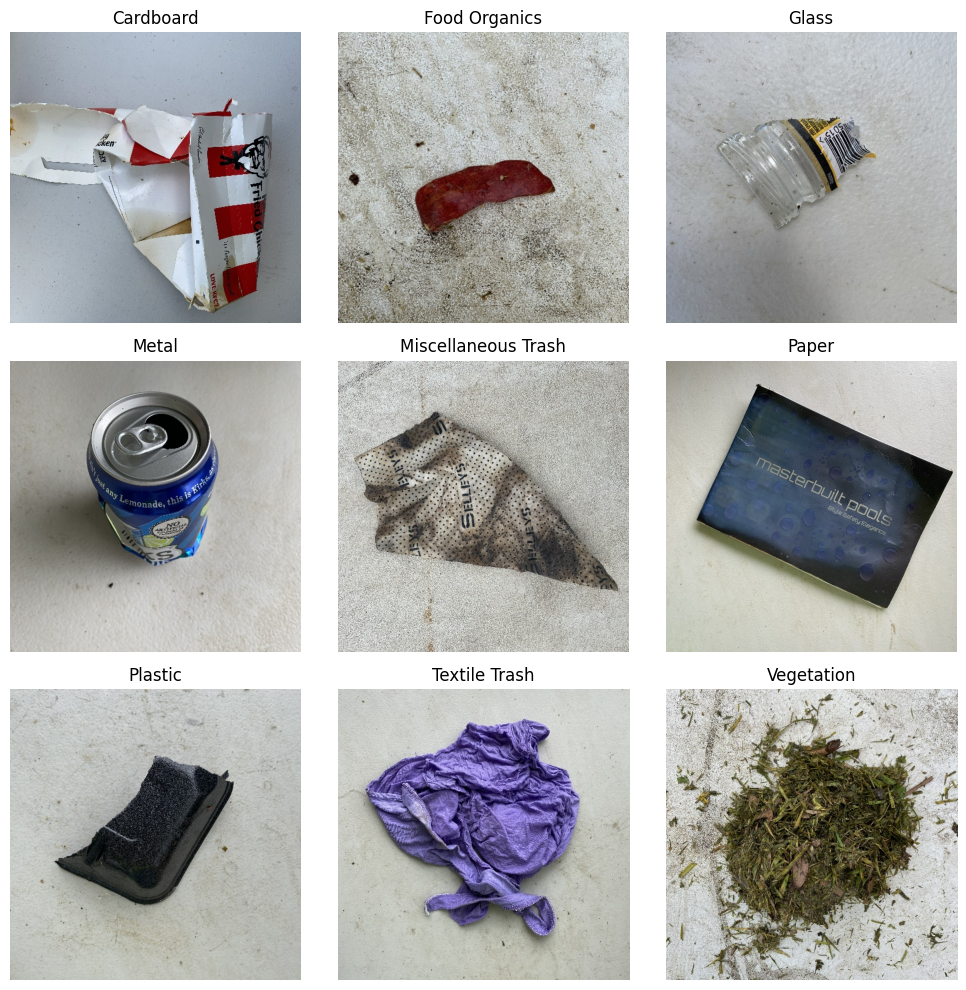

In [ ]:
# show one image from each class
plt.figure(figsize=(10, 10))

for i in range(len(class_names)):
    class_name = class_names[i]
    class_path = os.path.join(dataset_path, class_name)

    image_files = os.listdir(class_path)
    image_name = image_files[0]

    image_path = os.path.join(class_path, image_name)
    image = plt.imread(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Image paths and labels

In [ ]:
image_paths = []
labels = []

for class_number, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)

    image_files = os.listdir(class_path)
    image_files.sort()

    for image_name in image_files:
        image_path = os.path.join(class_path, image_name)

        image_paths.append(image_path)
        labels.append(class_number)

print("Images:", len(image_paths))
print("Labels:", len(labels))

Images: 4752
Labels: 4752


### Train, validation and test split

In [ ]:
# keep 70% for training
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=seed,
    stratify=labels
)

In [ ]:
# divide the remaining 30% equally
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=seed,
    stratify=temp_labels
)

In [ ]:
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

Training images: 3326
Validation images: 713
Testing images: 713


In [ ]:
print("Training:", round(len(train_paths) / total_images * 100, 2), "%")
print("Validation:", round(len(val_paths) / total_images * 100, 2), "%")
print("Testing:", round(len(test_paths) / total_images * 100, 2), "%")

Training: 69.99 %
Validation: 15.0 %
Testing: 15.0 %


### Image preprocessing

In [ ]:
def load_image(image_path, label):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(
        image,
        [image_height, image_width]
    )

    image = tf.cast(image, tf.float32)
    image = image / 255.0

    return image, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

train_ds = train_ds.map(load_image)

train_ds = train_ds.shuffle(
    len(train_paths),
    seed=seed
)

train_ds = train_ds.batch(batch_size)

In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = val_ds.map(load_image)
val_ds = val_ds.batch(batch_size)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

test_ds = test_ds.map(load_image)
test_ds = test_ds.batch(batch_size)

In [ ]:
for images, batch_labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", batch_labels.shape)

Image batch shape: (32, 64, 64, 3)
Label batch shape: (32,)


In [ ]:
for images, batch_labels in train_ds.take(1):
    print("Minimum value:", tf.reduce_min(images).numpy())
    print("Maximum value:", tf.reduce_max(images).numpy())

Minimum value: 0.0
Maximum value: 1.0


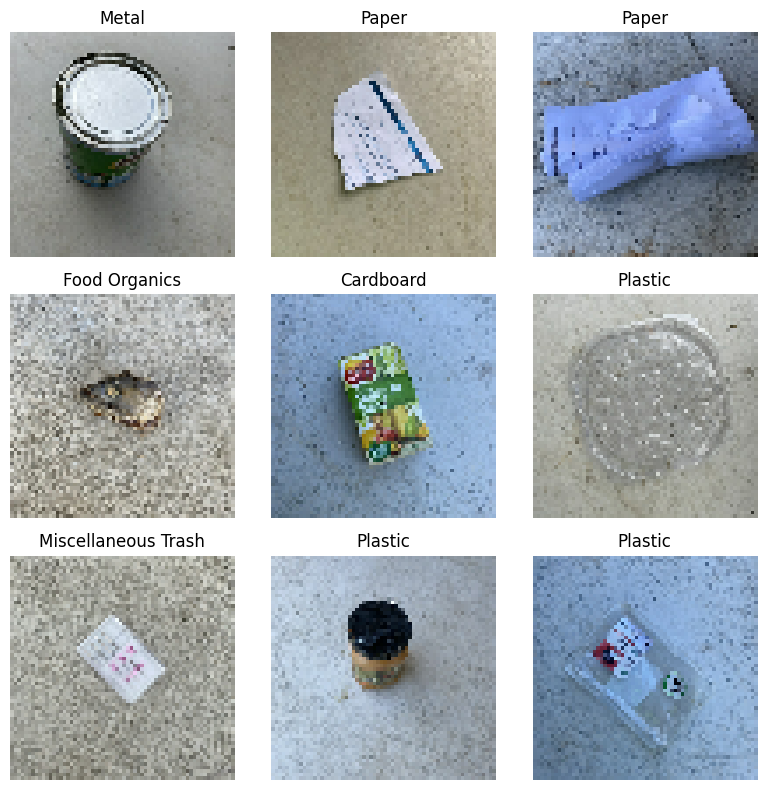

In [ ]:
for images, batch_labels in train_ds.take(1):

    plt.figure(figsize=(8, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[batch_labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_fast = (tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
                 .map(load_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .shuffle(len(train_paths), seed=seed)
                 .batch(batch_size)
                 .prefetch(AUTOTUNE))

val_ds_fast  = val_ds.cache().prefetch(AUTOTUNE)
test_ds_fast = test_ds.cache().prefetch(AUTOTUNE)

Define Model B (Depthwise Separable CNN)

In [ ]:
num_classes = len(class_names)

def build_model_b():
    inputs = layers.Input(shape=(image_height, image_width, 3))

    # Data augmentation (only active during training, 0 parameters)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    def bn(t):
        return layers.BatchNormalization(momentum=0.9)(t)

    # Standard conv stem (3 RGB channels)
    x = layers.Conv2D(16, 3, padding="same", use_bias=False)(x)
    x = bn(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)          # 32x32

    # Depthwise separable blocks
    for filters in [32, 64, 128]:          # 16x16, 8x8, 4x4
        x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False)(x)
        x = bn(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(2)(x)

    x = layers.SeparableConv2D(128, 3, padding="same", use_bias=False)(x)
    x = bn(x)
    x = layers.ReLU()(x)

    # Global average pooling avoids a huge fully connected layer
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="Model_B_DWSep")

model_b = build_model_b()
model_b.summary()

Model: "Model_B_DWSep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 32, 32, 32)     │           656 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 16, 16, 64)     │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 8, 8, 128)      │         8,768 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 4, 4, 128)      │        17,53

 Total params: 40,041 (156.41 KB)

 Trainable params: 39,305 (153.54 KB)

 Non-trainable params: 736 (2.88 KB)

Verify the Parameter Constraint (< 100,000)

In [ ]:
trainable_params = sum(tf.size(w).numpy() for w in model_b.trainable_weights)
total_params = model_b.count_params()

print(f"Trainable Parameters: {trainable_params:,}")
print(f"Total Parameters:     {total_params:,}")

assert trainable_params < 100_000, "Error: Parameter count exceeds 100k!"
print("Verification Passed: Model B is well under the 100,000 parameter limit.")

Trainable Parameters: 39,305
Total Parameters:     40,041
Verification Passed: Model B is well under the 100,000 parameter limit.


Train Model B and Measure Epoch Execution Time

In [ ]:
import time

# Compile the existing Model B
model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Custom callback to track execution time per epoch
class EpochTimeCallback(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self.epoch_start_time
        self.epoch_times.append(elapsed)

time_callback = EpochTimeCallback()

# Train Model B
history_b = model_b.fit(
    train_ds_fast,
    validation_data=val_ds_fast,
    epochs=epochs,
    callbacks=[time_callback]
)

# Calculate and display average time per epoch
avg_epoch_time = sum(time_callback.epoch_times) / len(time_callback.epoch_times)
print(f"\nAverage Execution Time per Epoch: {avg_epoch_time:.2f} seconds")

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.3527 - loss: 1.8107 - val_accuracy: 0.3927 - val_loss: 1.7303
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.4756 - loss: 1.4697 - val_accuracy: 0.3689 - val_loss: 1.7169
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.5147 - loss: 1.3420 - val_accuracy: 0.3633 - val_loss: 2.1468
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.5355 - loss: 1.2861 - val_accuracy: 0.4067 - val_loss: 1.8149
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.5499 - loss: 1.2480 - val_accuracy: 0.3478 - val_loss: 2.1631
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.5695 - loss: 1.1779 - val_accuracy: 0.3100 - val_loss: 2.1170
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.5902 - loss: 1.1501 - val_accuracy: 0.3703 - val_loss: 2.1863
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.5911 - loss: 1.1259

In [ ]:
# Compile the model
model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callback to save the best model weights based on validation accuracy
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="Dumindu_ModelB.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

# Train the model and assign the output to 'history'
history = model_b.fit(
    train_ds_fast,
    epochs=epochs,
    validation_data=val_ds_fast,
    callbacks=[checkpoint_cb]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.6675 - loss: 0.9054 - val_accuracy: 0.2805 - val_loss: 3.0096
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.6945 - loss: 0.8468 - val_accuracy: 0.4811 - val_loss: 1.5783
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.6876 - loss: 0.8609 - val_accuracy: 0.4698 - val_loss: 1.7984
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.6900 - loss: 0.8440 - val_accuracy: 0.4839 - val_loss: 1.5678
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.6981 - loss: 0.8369 - val_accuracy: 0.5512 - val_loss: 1.3514
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.6858 - loss: 0.8466 - val_accuracy: 0.4951 - val_loss: 1.6726
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.6999 - loss: 0.8314 - val_accuracy: 0.4067 - val_loss: 2.0839
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.7057 - loss: 0.8

Plot Loss & Accuracy Curves and Evaluate Test Data

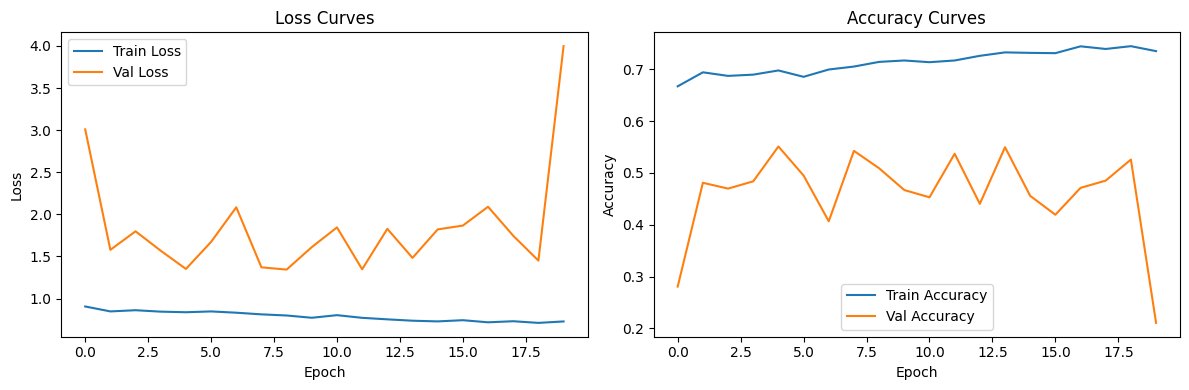

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5386 - loss: 1.3947
Test Accuracy: 53.86%
Test Loss:     1.3947


In [ ]:
# Plot curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Load the best epoch (chosen using validation accuracy, not test)
model_b = keras.models.load_model("Dumindu_ModelB.keras")

test_loss, test_acc = model_b.evaluate(test_ds_fast)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


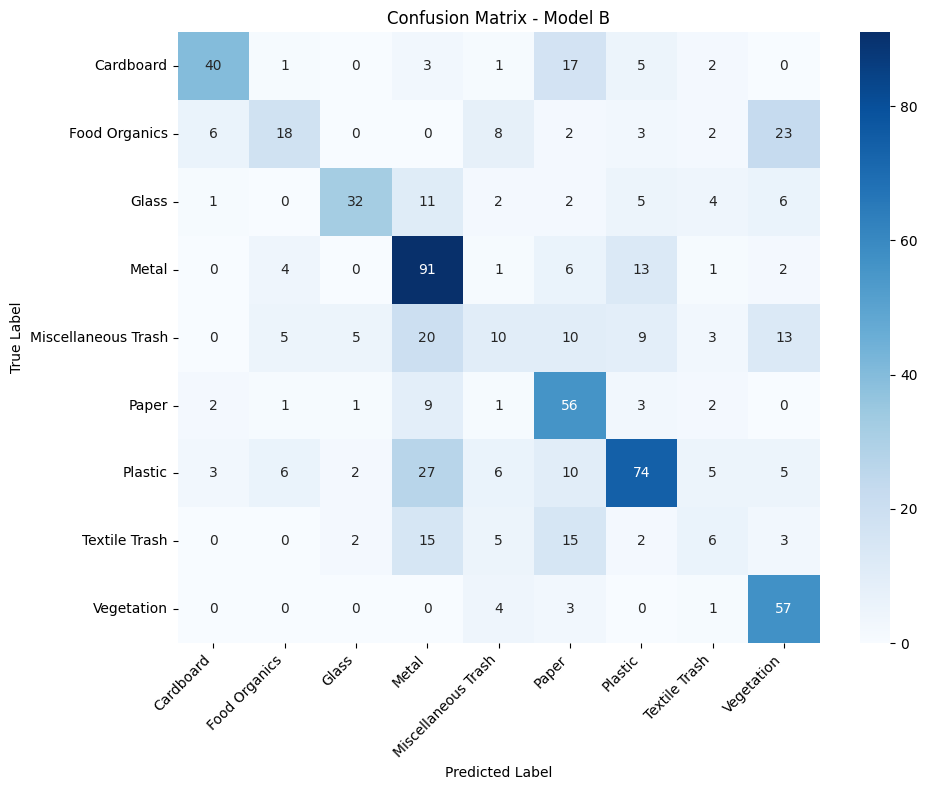

Classification Report:

                     precision    recall  f1-score   support

          Cardboard       0.77      0.58      0.66        69
      Food Organics       0.51      0.29      0.37        62
              Glass       0.76      0.51      0.61        63
              Metal       0.52      0.77      0.62       118
Miscellaneous Trash       0.26      0.13      0.18        75
              Paper       0.46      0.75      0.57        75
            Plastic       0.65      0.54      0.59       138
      Textile Trash       0.23      0.12      0.16        48
         Vegetation       0.52      0.88      0.66        65

           accuracy                           0.54       713
          macro avg       0.52      0.51      0.49       713
       weighted avg       0.54      0.54      0.52       713



In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Predict labels on the test dataset
y_pred_probs = model_b.predict(test_ds_fast)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds_fast], axis=0)

# 3. Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - Model B')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Print Detailed Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Export Model & Calculate Storage Size

In [ ]:
# Save native Keras format
model_b.save("Dumindu_ModelB.keras")
keras_size_kb = os.path.getsize("Dumindu_ModelB.keras") / 1024
print(f"Saved Keras Model Size: {keras_size_kb:.2f} KB")

# Convert to TFLite (Edge-device format)
converter = tf.lite.TFLiteConverter.from_keras_model(model_b)
tflite_model = converter.convert()

with open("model_b.tflite", "wb") as f:
    f.write(tflite_model)

tflite_size_kb = os.path.getsize("model_b.tflite") / 1024
print(f"TFLite Model Size:      {tflite_size_kb:.2f} KB")

Saved Keras Model Size: 575.11 KB
Saved artifact at '/tmp/tmpaumov0te'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  134766259496016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259686672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259686864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259684944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259686288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259690704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259686480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259690896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259691088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259695312: TensorSpec(shape=(), dtype=tf.resour

### Addressing Cardboard Precision via Class Weighting
Because Cardboard is a frequent target for misclassifications (false positives), we can compute balanced class weights using our training labels to penalize mistakes on less frequent classes or adjust training focus.

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calculate balanced class weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=np.array(train_labels)
)

# Create a dictionary mapping class indices to weights
class_weight_dict = {i: w for i, w in enumerate(weights)}
print("Calculated balanced class weights:")
for idx, class_name in enumerate(class_names):
    print(f"{class_name}: {class_weight_dict[idx]:.4f}")

Calculated balanced class weights:
Cardboard: 1.1441
Food Organics: 1.2832
Glass: 1.2570
Metal: 0.6683
Miscellaneous Trash: 1.0681
Paper: 1.0559
Plastic: 0.5730
Textile Trash: 1.6647
Vegetation: 1.2117


Now, we will rebuild and retrain Model B using these class weights to see if we can reduce false positives in the Cardboard class.

In [ ]:
# Rebuild model to start fresh
model_b_weighted = build_model_b()

# Compile
model_b_weighted.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callback to save the best model weights based on validation accuracy
checkpoint_weighted_cb = keras.callbacks.ModelCheckpoint(
    filepath="Dumindu_ModelB_Weighted.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

# Train with class weights
history_weighted = model_b_weighted.fit(
    train_ds_fast,
    epochs=epochs,
    validation_data=val_ds_fast,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_weighted_cb]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.3253 - loss: 1.7936 - val_accuracy: 0.1781 - val_loss: 3.3324
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.4564 - loss: 1.4717 - val_accuracy: 0.3142 - val_loss: 2.1166
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.4925 - loss: 1.3592 - val_accuracy: 0.3913 - val_loss: 1.8104
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.5120 - loss: 1.3060 - val_accuracy: 0.2104 - val_loss: 2.8082
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.5340 - loss: 1.2409 - val_accuracy: 0.2174 - val_loss: 2.4598
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.5409 - loss: 1.2009 - val_accuracy: 0.4432 - val_loss: 1.6160
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.5658 - loss: 1.1486 - val_accuracy: 0.3366 - val_loss: 1.9972
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.5655 - loss: 1

In [ ]:
# Evaluate the newly trained weighted model on the test dataset
model_b_weighted = keras.models.load_model("Dumindu_ModelB_Weighted.keras")

y_pred_probs_w = model_b_weighted.predict(test_ds_fast)
y_pred_w = np.argmax(y_pred_probs_w, axis=1)

print("Weighted Model Classification Report:\n")
print(classification_report(y_true, y_pred_w, target_names=class_names))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Weighted Model Classification Report:

                     precision    recall  f1-score   support

          Cardboard       0.31      0.93      0.47        69
      Food Organics       0.52      0.39      0.44        62
              Glass       0.86      0.60      0.71        63
              Metal       0.67      0.58      0.62       118
Miscellaneous Trash       0.30      0.32      0.31        75
              Paper       0.66      0.41      0.51        75
            Plastic       0.73      0.35      0.47       138
      Textile Trash       0.33      0.31      0.32        48
         Vegetation       0.63      0.75      0.69        65

           accuracy                           0.51       713
          macro avg       0.56      0.52      0.50       713
       weighted avg       0.58      0.51      0.51       713



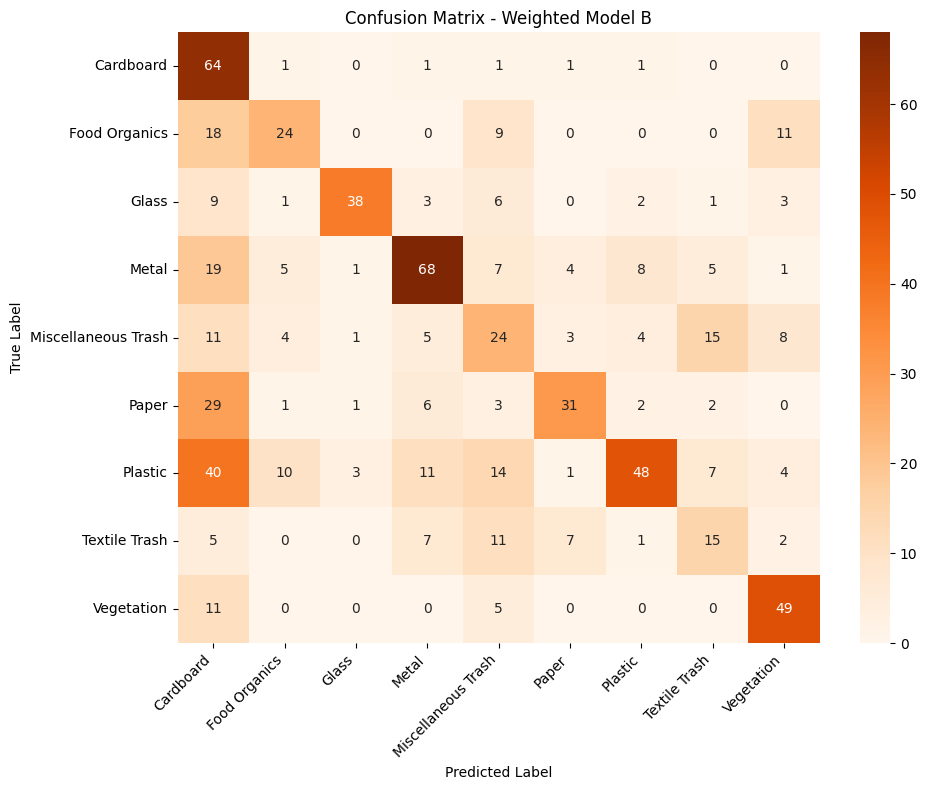

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix for the weighted model
cm_weighted = confusion_matrix(y_true, y_pred_w)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_weighted,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - Weighted Model B')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Find indices for Plastic and Food Organics
plastic_idx = class_names.index('Plastic')
food_idx = class_names.index('Food Organics')

# Filter predictions and true labels for reporting
for name, idx in [('Plastic', plastic_idx), ('Food Organics', food_idx)]:
    true_count = np.sum(y_true == idx)
    pred_count = np.sum(y_pred_w == idx)
    correct_count = np.sum((y_true == idx) & (y_pred_w == idx))

    precision = precision_score(y_true, y_pred_w, labels=[idx], average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred_w, labels=[idx], average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred_w, labels=[idx], average='macro', zero_division=0)

    print(f"=== Analysis for {name} ===")
    print(f"Actual {name} images in Test Set: {true_count}")
    print(f"Predicted as {name} by Model: {pred_count}")
    print(f"Correctly Predicted (True Positives): {correct_count}")
    print(f"Precision: {precision:.2%}")
    print(f"Recall (Sensitivity): {recall:.2%}")
    print(f"F1-Score: {f1:.2%}\n")


=== Analysis for Plastic ===
Actual Plastic images in Test Set: 138
Predicted as Plastic by Model: 66
Correctly Predicted (True Positives): 48
Precision: 72.73%
Recall (Sensitivity): 34.78%
F1-Score: 47.06%

=== Analysis for Food Organics ===
Actual Food Organics images in Test Set: 62
Predicted as Food Organics by Model: 46
Correctly Predicted (True Positives): 24
Precision: 52.17%
Recall (Sensitivity): 38.71%
F1-Score: 44.44%



=== Error breakdown for Actual PLASTIC images ===
  Classified as 'Cardboard': 40 times 
  Classified as 'Food Organics': 10 times 
  Classified as 'Glass': 3 times 
  Classified as 'Metal': 11 times 
  Classified as 'Miscellaneous Trash': 14 times 
  Classified as 'Paper': 1 times 
  Classified as 'Plastic': 48 times (CORRECT)
  Classified as 'Textile Trash': 7 times 
  Classified as 'Vegetation': 4 times 

=== Error breakdown for Actual FOOD ORGANICS images ===
  Classified as 'Cardboard': 18 times 
  Classified as 'Food Organics': 24 times (CORRECT)
  Classified as 'Miscellaneous Trash': 9 times 
  Classified as 'Vegetation': 11 times 


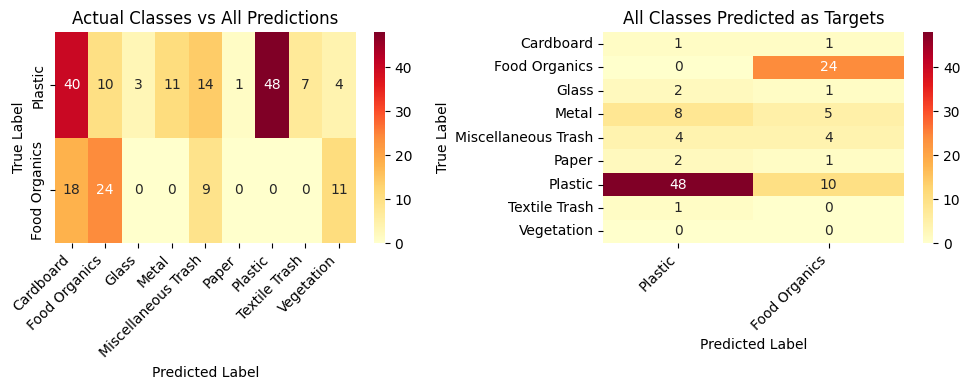

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract indices
p_idx = class_names.index('Plastic')
f_idx = class_names.index('Food Organics')

# We will extract rows corresponding to Plastic and Food Organics to see where actual instances are classified
# And columns corresponding to them to see what is being misclassified as Plastic/Food Organics
target_indices = [p_idx, f_idx]
target_names = ['Plastic', 'Food Organics']

# Print detailed error mapping from the confusion matrix
print("=== Error breakdown for Actual PLASTIC images ===")
for i, count in enumerate(cm_weighted[p_idx]):
    if count > 0:
        print(f"  Classified as '{class_names[i]}': {count} times {'(CORRECT)' if i==p_idx else ''}")

print("\n=== Error breakdown for Actual FOOD ORGANICS images ===")
for i, count in enumerate(cm_weighted[f_idx]):
    if count > 0:
        print(f"  Classified as '{class_names[i]}': {count} times {'(CORRECT)' if i==f_idx else ''}")

# Create a visualization of the subgrid representing conflicts between Plastic, Food Organics and others
plt.figure(figsize=(10, 4))

# Subset 1: Rows of Plastic and Food Organics against all classes
plt.subplot(1, 2, 1)
sns.heatmap(
    cm_weighted[target_indices, :],
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=class_names,
    yticklabels=target_names
)
plt.title('Actual Classes vs All Predictions')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')

# Subset 2: All classes against Predictions of Plastic and Food Organics
plt.subplot(1, 2, 2)
sns.heatmap(
    cm_weighted[:, target_indices],
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=target_names,
    yticklabels=class_names
)
plt.title('All Classes Predicted as Targets')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Found 14 actual Plastic images misclassified as Miscellaneous Trash.


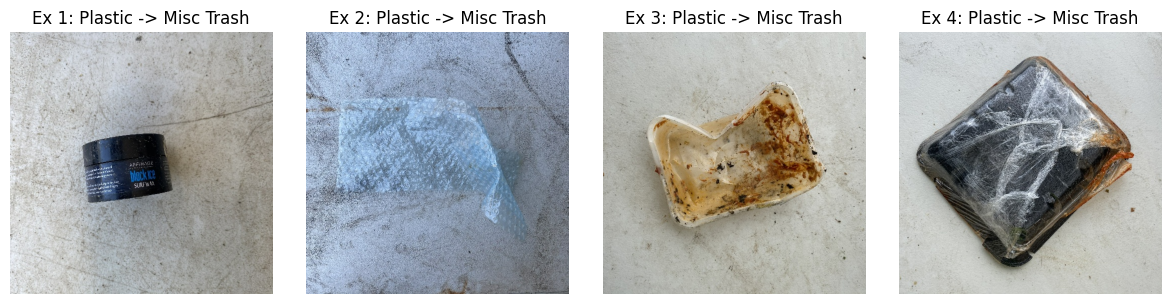

In [ ]:
import matplotlib.pyplot as plt

# Find indices where actual is Plastic and predicted is Miscellaneous Trash
plastic_idx = class_names.index('Plastic')
misc_idx = class_names.index('Miscellaneous Trash')

misclassified_indices = np.where((y_true == plastic_idx) & (y_pred_w == misc_idx))[0]
print(f"Found {len(misclassified_indices)} actual Plastic images misclassified as Miscellaneous Trash.")

# Plot up to 4 example images
num_examples = min(4, len(misclassified_indices))
if num_examples > 0:
    plt.figure(figsize=(12, 3))
    for i in range(num_examples):
        idx = misclassified_indices[i]
        img_path = test_paths[idx]
        img = plt.imread(img_path)

        plt.subplot(1, num_examples, i + 1)
        plt.imshow(img)
        plt.title(f"Ex {i+1}: Plastic -> Misc Trash")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No matching misclassifications found to display.")

In [ ]:
# Load the best weighted model
model_b_weighted = keras.models.load_model("Dumindu_ModelB_Weighted.keras")

# Convert to TFLite
converter_weighted = tf.lite.TFLiteConverter.from_keras_model(model_b_weighted)
tflite_model_weighted = converter_weighted.convert()

# Save the TFLite model
tflite_weighted_path = "model_b_weighted.tflite"
with open(tflite_weighted_path, "wb") as f:
    f.write(tflite_model_weighted)

# Display the storage size
tflite_weighted_size_kb = os.path.getsize(tflite_weighted_path) / 1024
print(f"Weighted TFLite Model Size: {tflite_weighted_size_kb:.2f} KB")

Saved artifact at '/tmp/tmpsyu_pfun'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  134766685845264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259495056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259493520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766685835088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766685840848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259490640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259495248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259499088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259486992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259486800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259498896

In [ ]:
# 1. Set up converter with dynamic range quantization
converter_quant = tf.lite.TFLiteConverter.from_keras_model(model_b_weighted)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]

# 2. Convert the model
tflite_quant_model = converter_quant.convert()

# 3. Save the quantized TFLite model
tflite_quant_path = "model_b_weighted_quant.tflite"
with open(tflite_quant_path, "wb") as f:
    f.write(tflite_quant_model)

# 4. Measure size and reduction percentage
tflite_quant_size_kb = os.path.getsize(tflite_quant_path) / 1024
size_reduction = (1 - (tflite_quant_size_kb / tflite_weighted_size_kb)) * 100

print(f"Original TFLite Model Size:  {tflite_weighted_size_kb:.2f} KB")
print(f"Quantized TFLite Model Size: {tflite_quant_size_kb:.2f} KB")
print(f"Size Reduction:             {size_reduction:.2f}%")

Saved artifact at '/tmp/tmp_u_bt49t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  134766685845264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259495056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259493520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766685835088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766685840848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259490640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259495248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259499088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259486992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259486800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134766259498896

### Fine-Tuning Specifically for the Plastic Class
To address the low recall on Plastic, we will assign a much higher training class weight to `Plastic` and fine-tune our weighted model for 5 additional epochs.

In [ ]:
# 1. Create custom class weights with a heavily boosted weight for Plastic
fine_tune_weights = class_weight_dict.copy()
plastic_idx = class_names.index('Plastic')

# Boost the Plastic weight significantly to prioritize learning its features
fine_tune_weights[plastic_idx] = 2.0

print("Adjusted Fine-Tuning Class Weights:")
for idx, class_name in enumerate(class_names):
    print(f"{class_name}: {fine_tune_weights[idx]:.4f}")

Adjusted Fine-Tuning Class Weights:
Cardboard: 1.1441
Food Organics: 1.2832
Glass: 1.2570
Metal: 0.6683
Miscellaneous Trash: 1.0681
Paper: 1.0559
Plastic: 2.0000
Textile Trash: 1.6647
Vegetation: 1.2117


In [ ]:
# 2. Compile with a lower learning rate for stable fine-tuning adjustments
model_b_weighted.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Fine-tune for 5 additional epochs
fine_tune_history = model_b_weighted.fit(
    train_ds_fast,
    epochs=5,
    validation_data=val_ds_fast,
    class_weight=fine_tune_weights
)

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.6452 - loss: 1.1907 - val_accuracy: 0.4628 - val_loss: 1.5778
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.6341 - loss: 1.1585 - val_accuracy: 0.4670 - val_loss: 1.6199
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.6500 - loss: 1.1218 - val_accuracy: 0.4530 - val_loss: 1.6422
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.6597 - loss: 1.1187 - val_accuracy: 0.4698 - val_loss: 1.6493
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.6515 - loss: 1.1199 - val_accuracy: 0.5091 - val_loss: 1.4822


In [ ]:
# 4. Evaluate the fine-tuned model on test set to see the impact
y_pred_ft_probs = model_b_weighted.predict(test_ds_fast)
y_pred_ft = np.argmax(y_pred_ft_probs, axis=1)

print("\nFine-Tuned Classification Report:\n")
print(classification_report(y_true, y_pred_ft, target_names=class_names))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

Fine-Tuned Classification Report:

                     precision    recall  f1-score   support

          Cardboard       0.39      0.87      0.54        69
      Food Organics       0.59      0.26      0.36        62
              Glass       0.86      0.49      0.63        63
              Metal       0.77      0.41      0.53       118
Miscellaneous Trash       0.42      0.25      0.32        75
              Paper       0.43      0.51      0.46        75
            Plastic       0.52      0.72      0.60       138
      Textile Trash       0.50      0.21      0.29        48
         Vegetation       0.55      0.72      0.63        65

           accuracy                           0.52       713
          macro avg       0.56      0.49      0.48       713
       weighted avg       0.57      0.52      0.50       713

